In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print("Model is ready")

c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model is ready


In [8]:
from langchain.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults

search_tool = DuckDuckGoSearchResults()

# Custom tools
@tool
def get_weather(city: str) -> str:
    """Get the weather for a city"""
    return f"The weather in {city} is sunny with 32 degree celsius"

@tool
def get_stock_price(stock_name: str) -> str:
    """Returns the current stock price of a given stock name"""
    prices = {"Zensar": "500.50 INR", "Google": "730 INR"}
    return prices.get(stock_name, f"Unknown stock name {stock_name}")

@tool
def get_news(subject: str) -> str:
    """Gets the news for a given subject"""
    return search_tool.invoke(subject)

print("Tools are ready!!")

Tools are ready!!


In [11]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=[get_weather, get_stock_price, get_news],
    system_prompt="You are a helpful assistant that can provide weather information for cities. Please don't use your own information and use tools provided to you. If user asks weather information then call get_weather tool and if user asks stock information then call get_stock_price tool. Any news related request you can call get_news tool"
)
print('Agent is ready')


Agent is ready


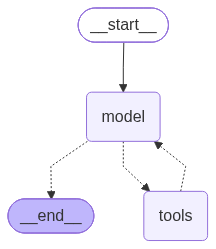

In [12]:
agent

In [5]:
response = agent.invoke({"messages": [
    {"role": "user", "content": "Which is the capital city of India?"}
]})
response

{'messages': [HumanMessage(content='Which is the capital city of India?', additional_kwargs={}, response_metadata={}, id='dd10046e-037b-469d-90bf-2cb67e91f009'),
  AIMessage(content='The capital city of India is **New\u202fDelhi**.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-08T09:07:18.629930534Z', 'done': True, 'done_reason': 'stop', 'total_duration': 402491205, 'load_duration': None, 'prompt_eval_count': 211, 'prompt_eval_duration': None, 'eval_count': 63, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a08045-8591-7332-b31f-8f0e8e0c6bbe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 211, 'output_tokens': 63, 'total_tokens': 274})]}

In [6]:
response = agent.invoke({"messages": [
    {"role": "user", "content": "What is the weather today in Mumbai?"}
]})
response

{'messages': [HumanMessage(content='What is the weather today in Mumbai?', additional_kwargs={}, response_metadata={}, id='10672e7e-1dd7-4677-a1a2-d73700e9e315'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-08T09:13:15.108883522Z', 'done': True, 'done_reason': 'stop', 'total_duration': 363252219, 'load_duration': None, 'prompt_eval_count': 211, 'prompt_eval_duration': None, 'eval_count': 38, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0804a-f717-78d1-8db3-8cc89c3bb968-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Mumbai'}, 'id': '5818fd89-1dfe-4baf-abef-77df218cc556', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 211, 'output_tokens': 38, 'total_tokens': 249}),
  ToolMessage(content='The weather in Mumbai is sunny with 32 degree celsius', name='get_weather', id='3bf287e0-6061-4f87-b0bc-fbee39c028d2', tool

In [7]:
response = agent.invoke({"messages": [
    {"role": "user", "content": "What is the stock price of Google?"}
]})
response

{'messages': [HumanMessage(content='What is the stock price of Google?', additional_kwargs={}, response_metadata={}, id='756d33d9-ae21-42db-9504-a2152d678f5a'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-08T09:23:22.790920304Z', 'done': True, 'done_reason': 'stop', 'total_duration': 668920013, 'load_duration': None, 'prompt_eval_count': 211, 'prompt_eval_duration': None, 'eval_count': 97, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a08054-3b00-7d03-8843-417d85fa827a-0', tool_calls=[{'name': 'get_stock_price', 'args': {'stock_name': 'Google'}, 'id': '8dfb97aa-c00a-4882-acc5-a0981f14efe3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 211, 'output_tokens': 97, 'total_tokens': 308}),
  ToolMessage(content='730 INR', name='get_stock_price', id='689a65a8-60ca-41d0-9e81-ae721a50ddba', tool_call_id='8dfb97aa-c00a-4882-acc5-

In [13]:
response = agent.invoke({"messages": [
    {"role": "user", "content": "Recent Nepal incident news"}
]})
response

{'messages': [HumanMessage(content='Recent Nepal incident news', additional_kwargs={}, response_metadata={}, id='7d44089d-ec62-40f2-bb35-879857091f7a'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-08T09:34:03.019177741Z', 'done': True, 'done_reason': 'stop', 'total_duration': 479302842, 'load_duration': None, 'prompt_eval_count': 241, 'prompt_eval_duration': None, 'eval_count': 80, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0805d-fdd8-7a71-b7b6-51ffab69de33-0', tool_calls=[{'name': 'get_news', 'args': {'subject': 'Nepal incident'}, 'id': '109a6e74-61e5-4f72-9363-1c1e4b74e6f6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 241, 'output_tokens': 80, 'total_tokens': 321}),
  ToolMessage(content='snippet: Rasuwa District Landslides in 2026 2026 Nepal floods Natural disasters in Nepal Hidden categories: Articles with sho